In [5]:
from questions import questions
print(len(questions))

100


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1320.87it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


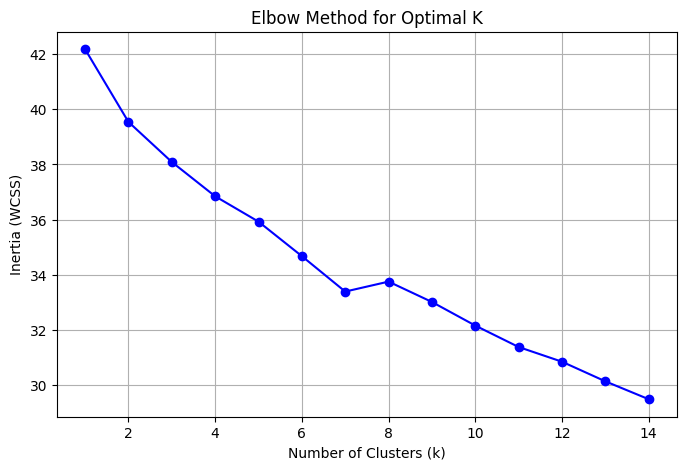

In [7]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from langchain_huggingface import HuggingFaceEmbeddings

embedding_function = HuggingFaceEmbeddings( model_name="BAAI/bge-small-en-v1.5")

question_vectors = embedding_function.embed_documents(questions)
X = np.array(question_vectors)


pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X)

inertia_values = []
k_range = range(1, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_reduced)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

In [14]:
import joblib

final_kmeans = KMeans(n_clusters=7, random_state=42, n_init=20)
final_kmeans.fit(X_reduced)

joblib.dump(final_kmeans, 'model/it_support_clusters.joblib')
joblib.dump(pca, 'model/pca_transformer.joblib')

['model/pca_transformer.joblib']

In [15]:
import joblib


loaded_kmeans = joblib.load('model/it_support_clusters.joblib')
loaded_pca = joblib.load('model/pca_transformer.joblib')

new_vec = embedding_function.embed_query("How do I fix a blue screen?")
new_vec_reduced = loaded_pca.transform([new_vec])
cluster_id = loaded_kmeans.predict(new_vec_reduced)

print(f"This question belongs to Cluster {cluster_id[0]}")

This question belongs to Cluster 1
